In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%cd ..

/home/marysia/Documents/GitHub/MRI_machine_learning


In [52]:
df = pd.read_csv(f'data/preprocessed_atlas/positive_norm_confirmed_a2009/all_concatenated_prawidlowy.csv', sep=None, engine='python', dtype={'identifier': str})
df = df.dropna()
df = df[df['IF_FIRST'] == 1]
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df = df[(df['age'] >= 0) & (df['age'] <= 100)]

In [4]:
def read_pathological_data(type='gleboki'):
    df_path = pd.read_csv(f'data/preprocessed_atlas/positive_norm_confirmed_a2009/leave_out_{type}.csv', sep=None, engine='python', dtype={'identifier': str})

    cols_to_check = df_path.columns.difference(['L_HEARING_TYPE', 'P_HEARING_TYPE'])
    df_path = df_path.dropna(subset=cols_to_check).copy()


    df_path = df_path[df_path['IF_FIRST'] == 1]
    df_path['DATA_BADANIA_MRI'] = pd.to_datetime(df_path['DATA_BADANIA_MRI'], format='%Y-%m-%d')
    df_path['DATA_BADANIA'] = pd.to_datetime(df_path['DATA_BADANIA'], dayfirst=True, errors='coerce')
    df_path = df_path[df_path['DATA_BADANIA_MRI'] > df_path['DATA_BADANIA']]

    df_path['age'] = pd.to_numeric(df['age'], errors='coerce')
    df_path = df_path[(df_path['age'] >= 0.5) & (df_path['age'] <= 100)]

    return df_path

In [55]:
df_gleboki = read_pathological_data('gleboki')
df_znaczny = read_pathological_data('znaczny')
df_umiarkowany = read_pathological_data('umiarkowany')
df_lekki = read_pathological_data('lekki')

In [14]:
def plot_struct(ax, df, df_hearing, type, column, sex='M'):
    if sex =='M':
        df_sel = df[df['male']==1]
        df_hearing = df_hearing[df_hearing['male']==1]
    else:        
        df_sel = df[df['male']==0]
        df_hearing = df_hearing[df_hearing['male']==0]

    ax.scatter(df_sel['age'], df_sel[column], alpha=0.8, label='prawidłowy')
    ax.scatter(df_hearing['age'], df_hearing[column], alpha=0.8, label=type)

    coeffs_norm = np.polyfit(df_sel['age'], df_sel[column], deg=2)
    poly_norm = np.poly1d(coeffs_norm)

    coeffs_deep = np.polyfit(df_hearing['age'], df_hearing[column], deg=2)
    poly_deep = np.poly1d(coeffs_deep)

    age_space = np.linspace(min(df_sel['age'].min(), df_hearing['age'].min()),
                            max(df_sel['age'].max(), df_hearing['age'].max()), 300)

    ax.plot(age_space, poly_norm(age_space), label='fit prawidłowy', linewidth=2)
    ax.plot(age_space, poly_deep(age_space), label=f'fit {type}', linewidth=2)

    ax.set_xlabel("Wiek")
    ax.set_ylabel(f"Wartość {column}")
    ax.legend()


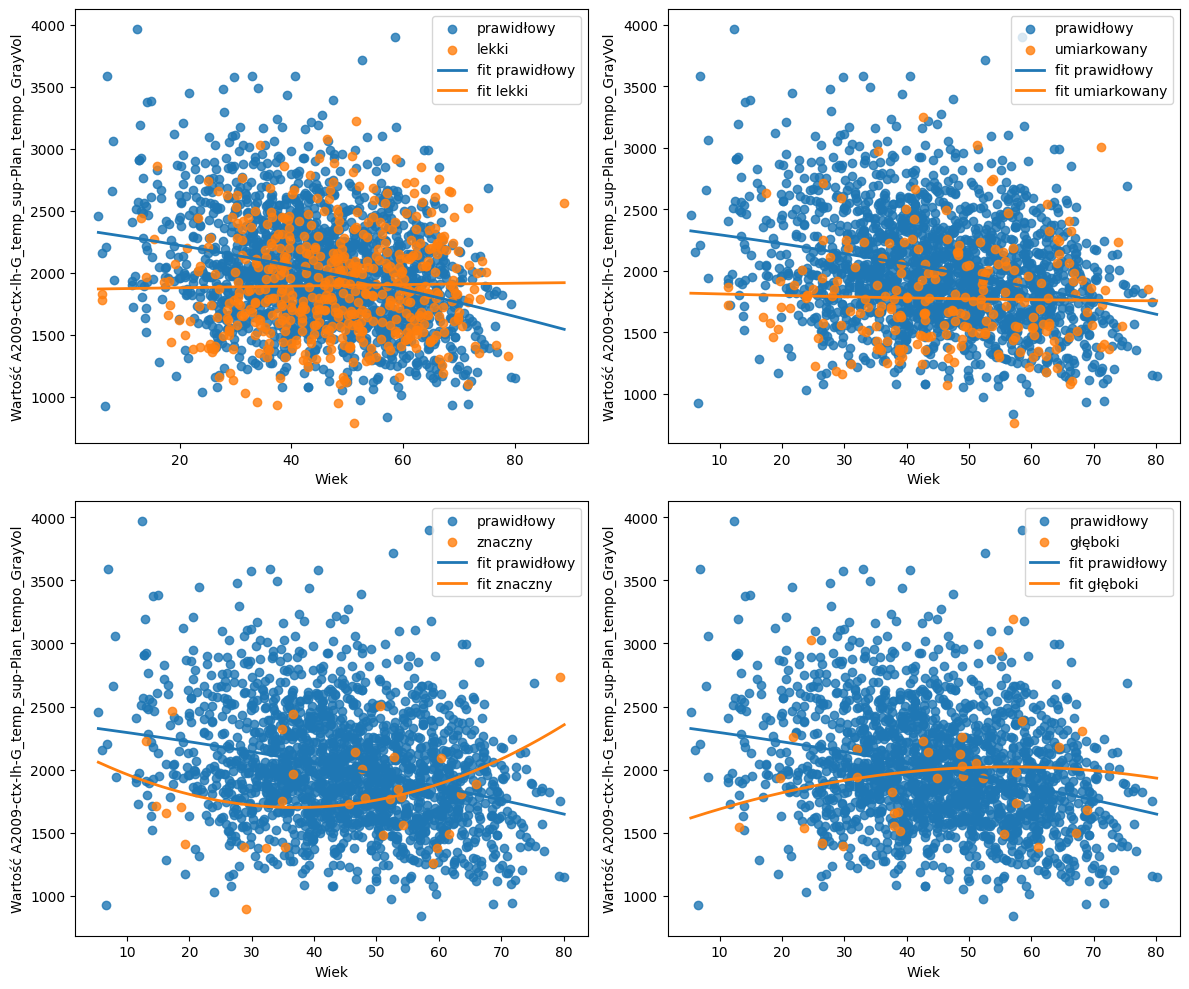

In [ ]:
#dyskryminacja dziwekow mowy
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_GrayVol', sex='M')

plt.tight_layout()
plt.show()


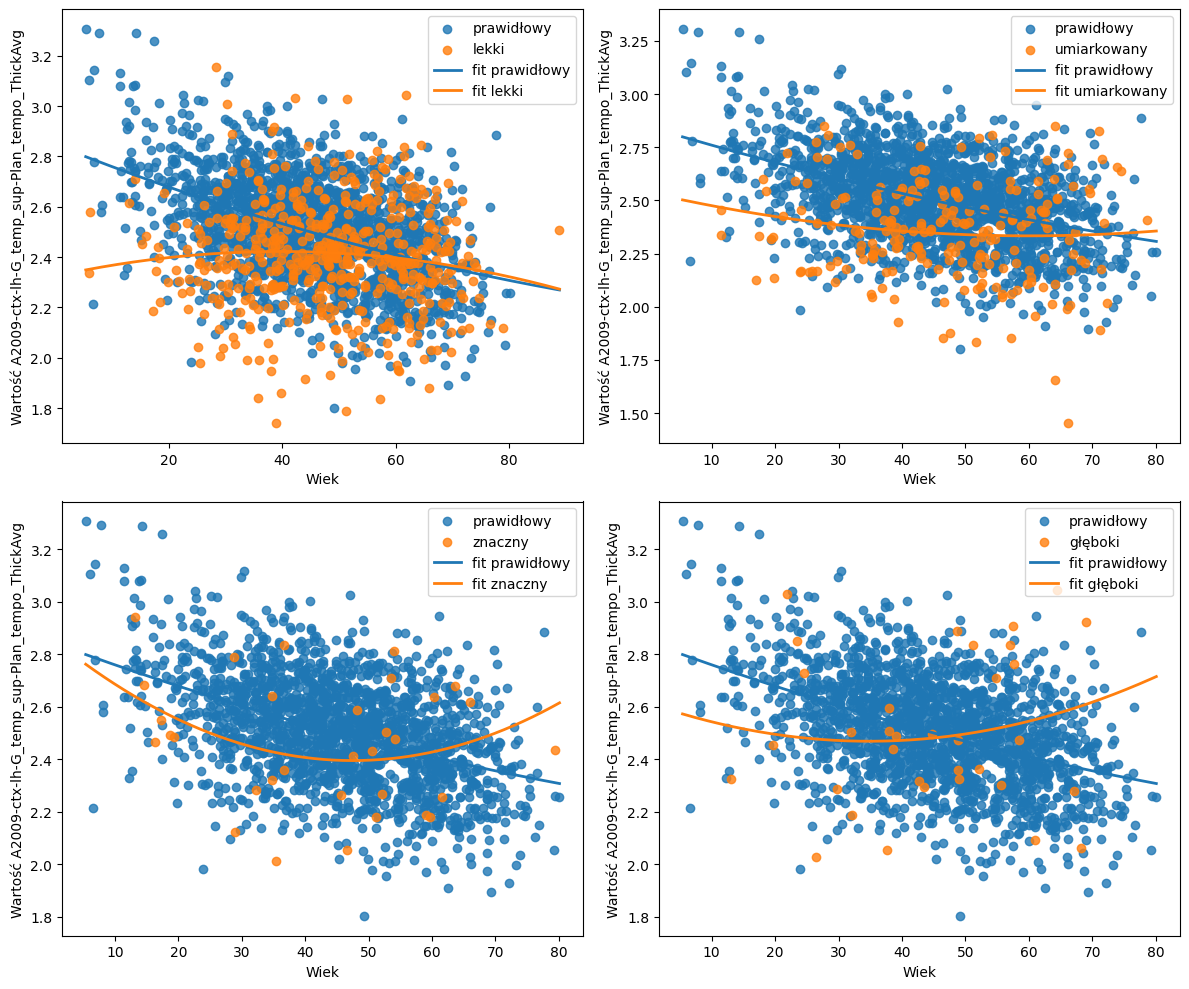

In [19]:
#dyskryminacja dziwekow mowy
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_ThickAvg', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_ThickAvg', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_ThickAvg', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_temp_sup-Plan_tempo_ThickAvg', sex='M')

plt.tight_layout()
plt.show()

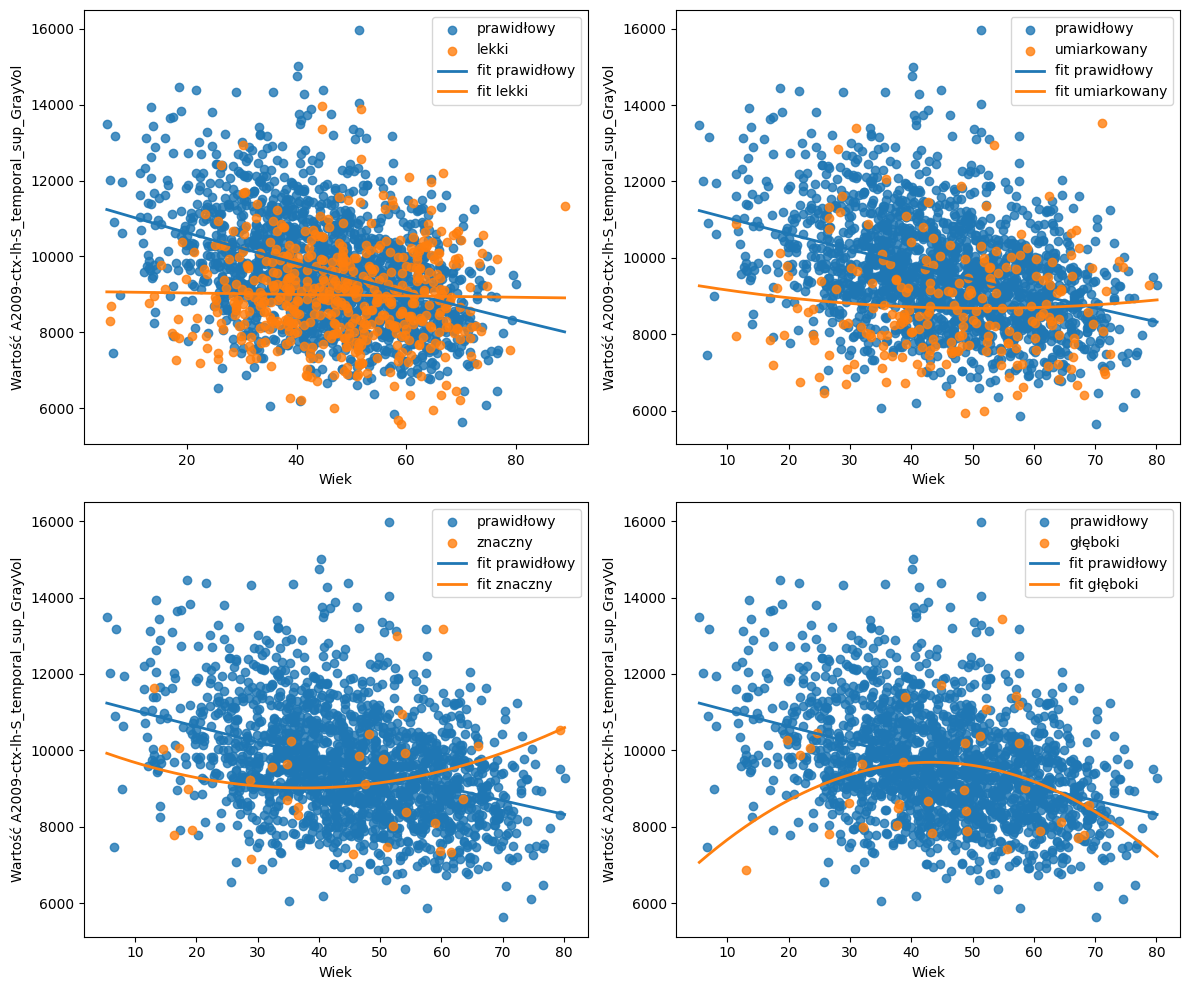

In [ ]:
#rozpoznawanie znaczenia wyrazow
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-S_temporal_sup_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-S_temporal_sup_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-S_temporal_sup_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-S_temporal_sup_GrayVol', sex='M')

plt.tight_layout()
plt.show()

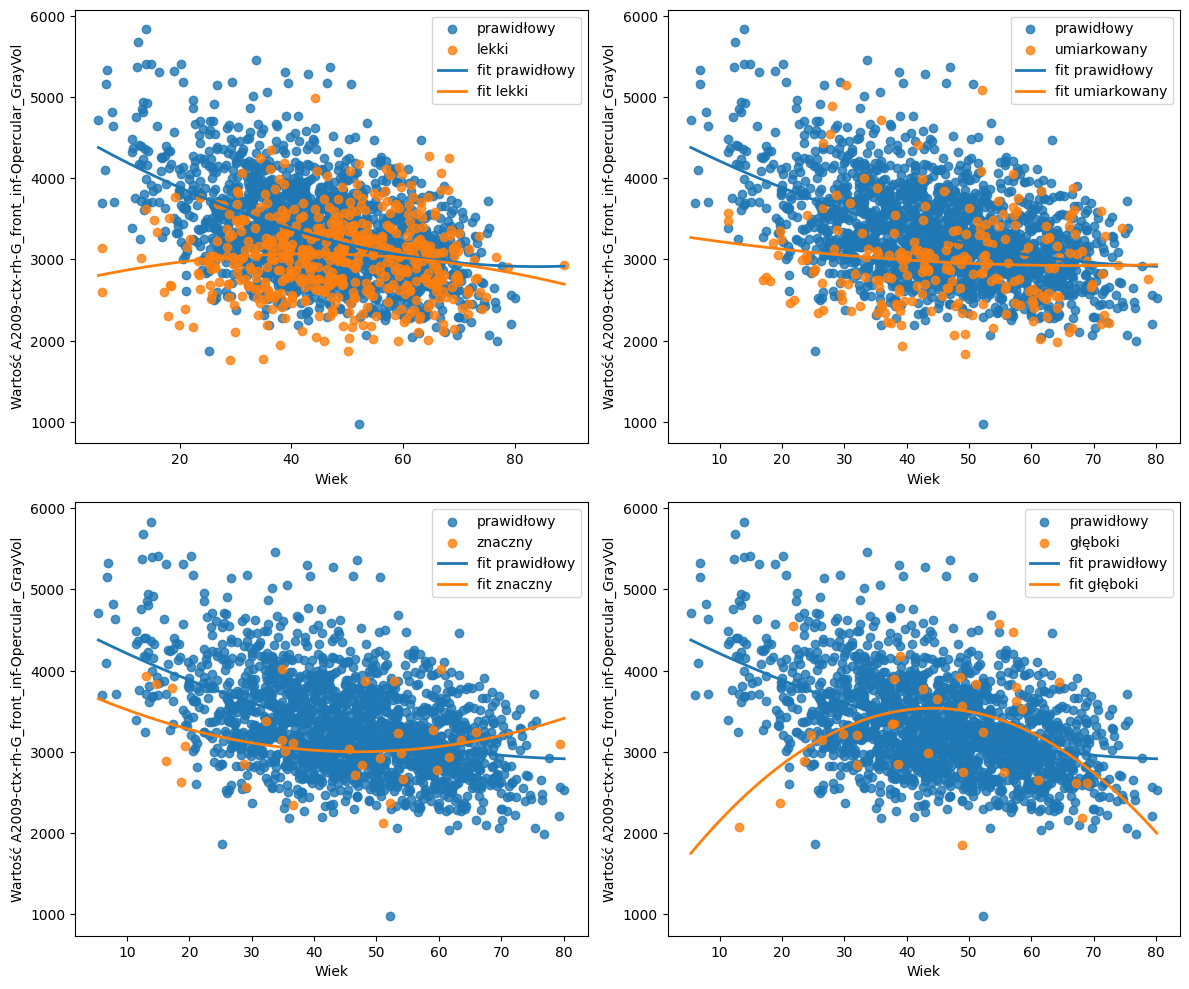

In [22]:
#generowanie mowy, polaczenie ze sluchem
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-rh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-rh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-rh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-rh-G_front_inf-Opercular_GrayVol', sex='M')

plt.tight_layout()
plt.show()

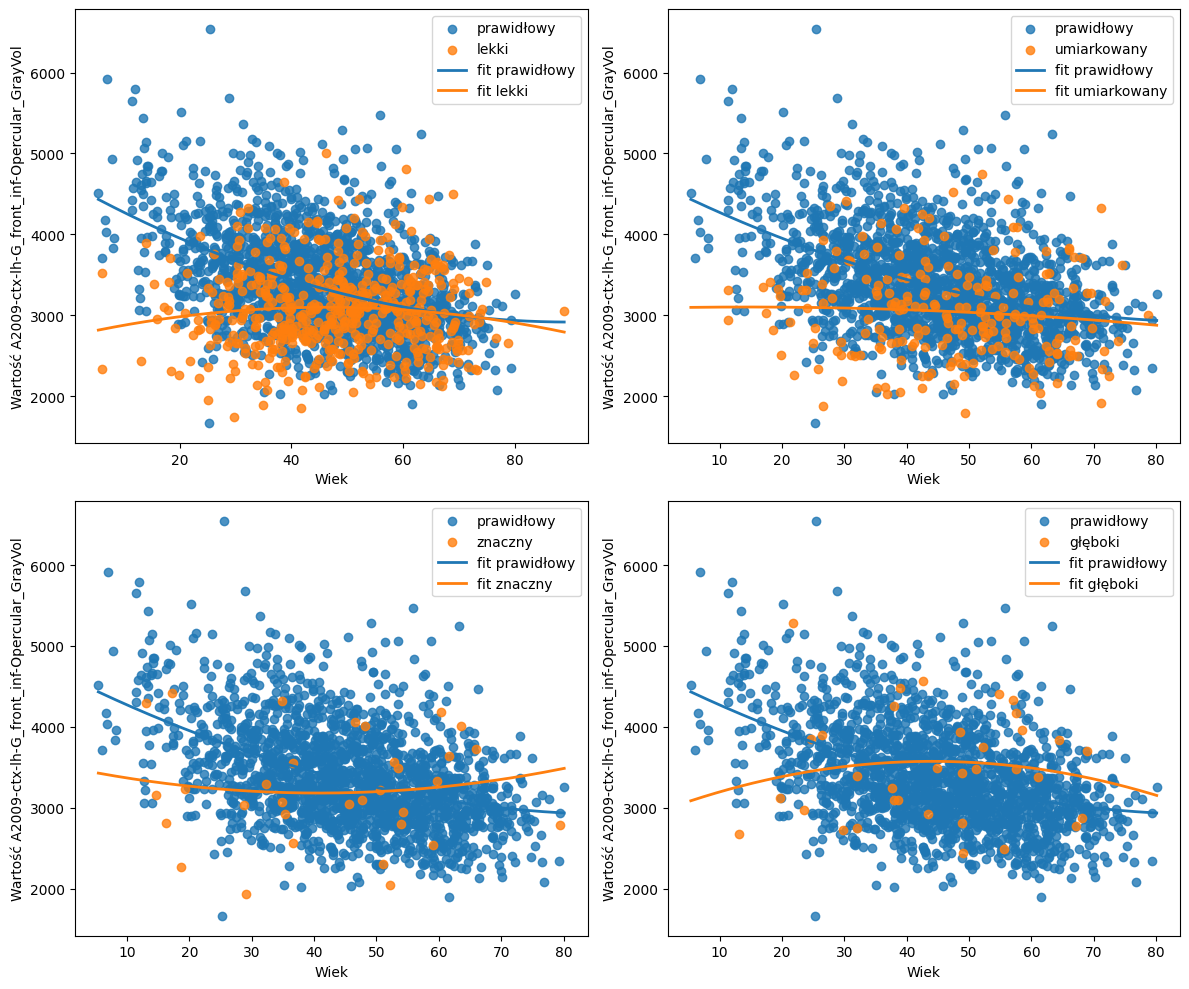

In [24]:
#generowanie mowy, polaczenie ze sluchem
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_front_inf-Opercular_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_front_inf-Opercular_GrayVol', sex='M')

plt.tight_layout()
plt.show()

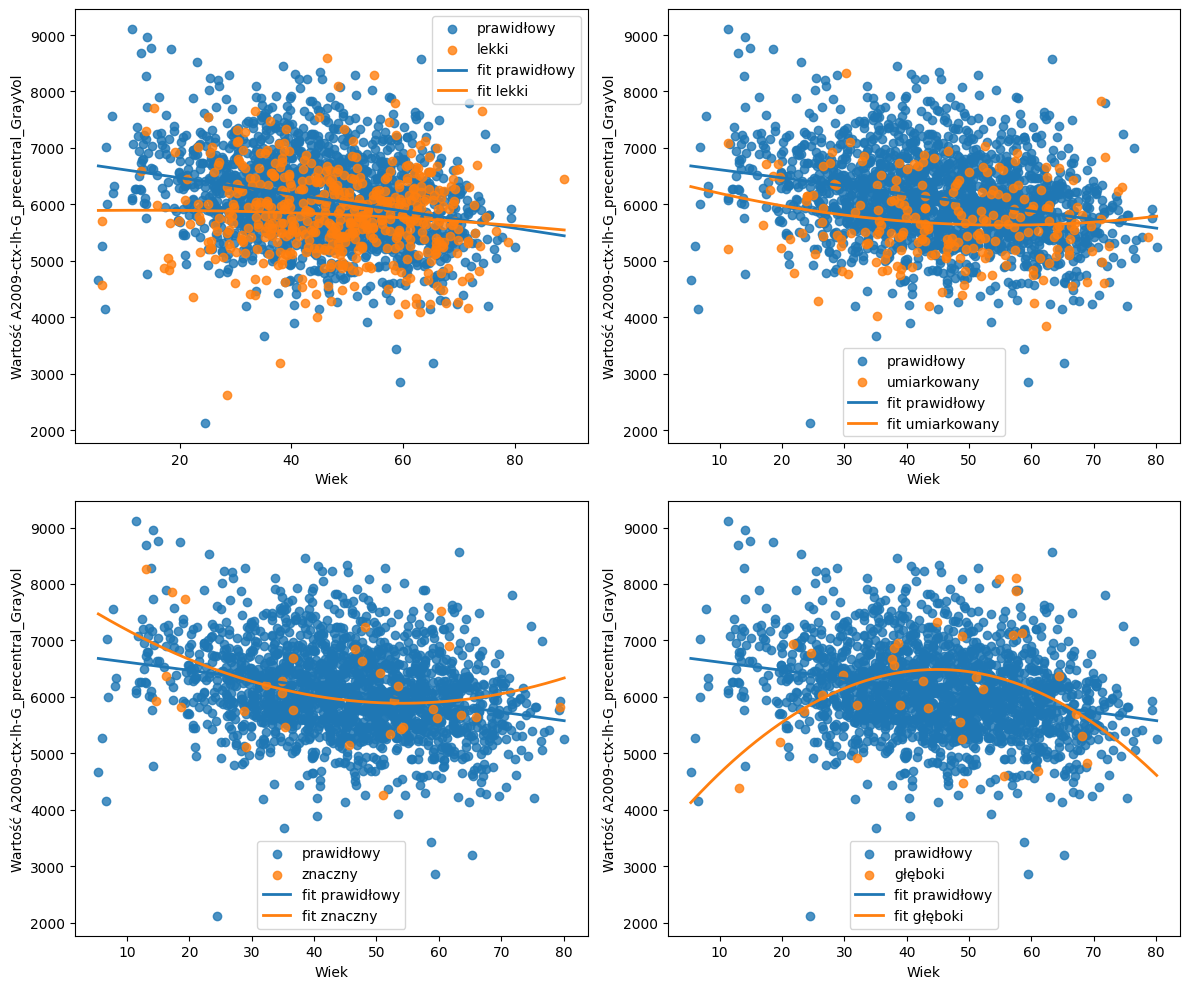

In [25]:
#ruch, planowanie
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_precentral_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_precentral_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_precentral_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_precentral_GrayVol', sex='M')

plt.tight_layout()
plt.show()

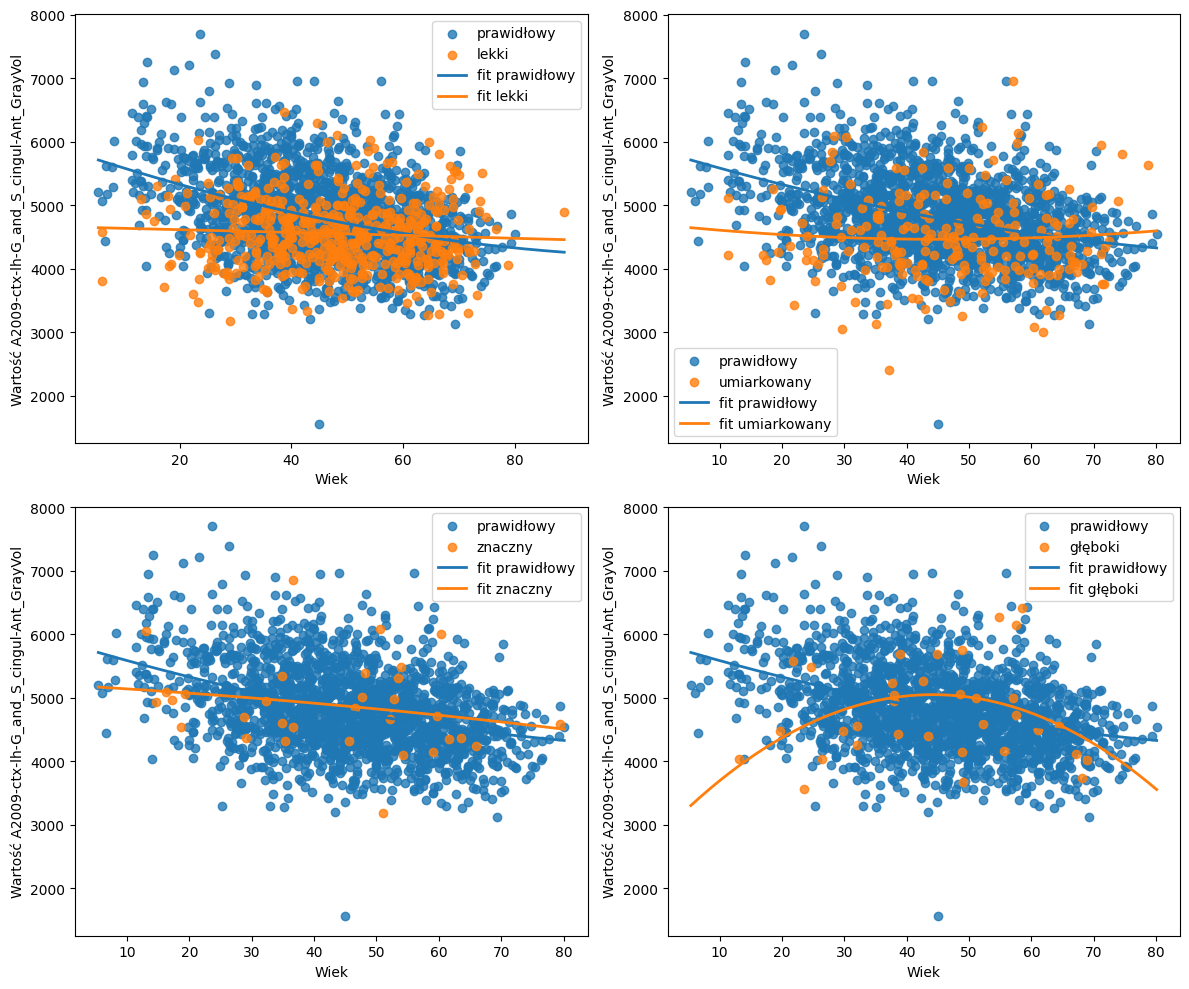

In [27]:
#kontrola wykonywania zadan
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_and_S_cingul-Ant_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_and_S_cingul-Ant_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_and_S_cingul-Ant_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_and_S_cingul-Ant_GrayVol', sex='M')

plt.tight_layout()
plt.show()

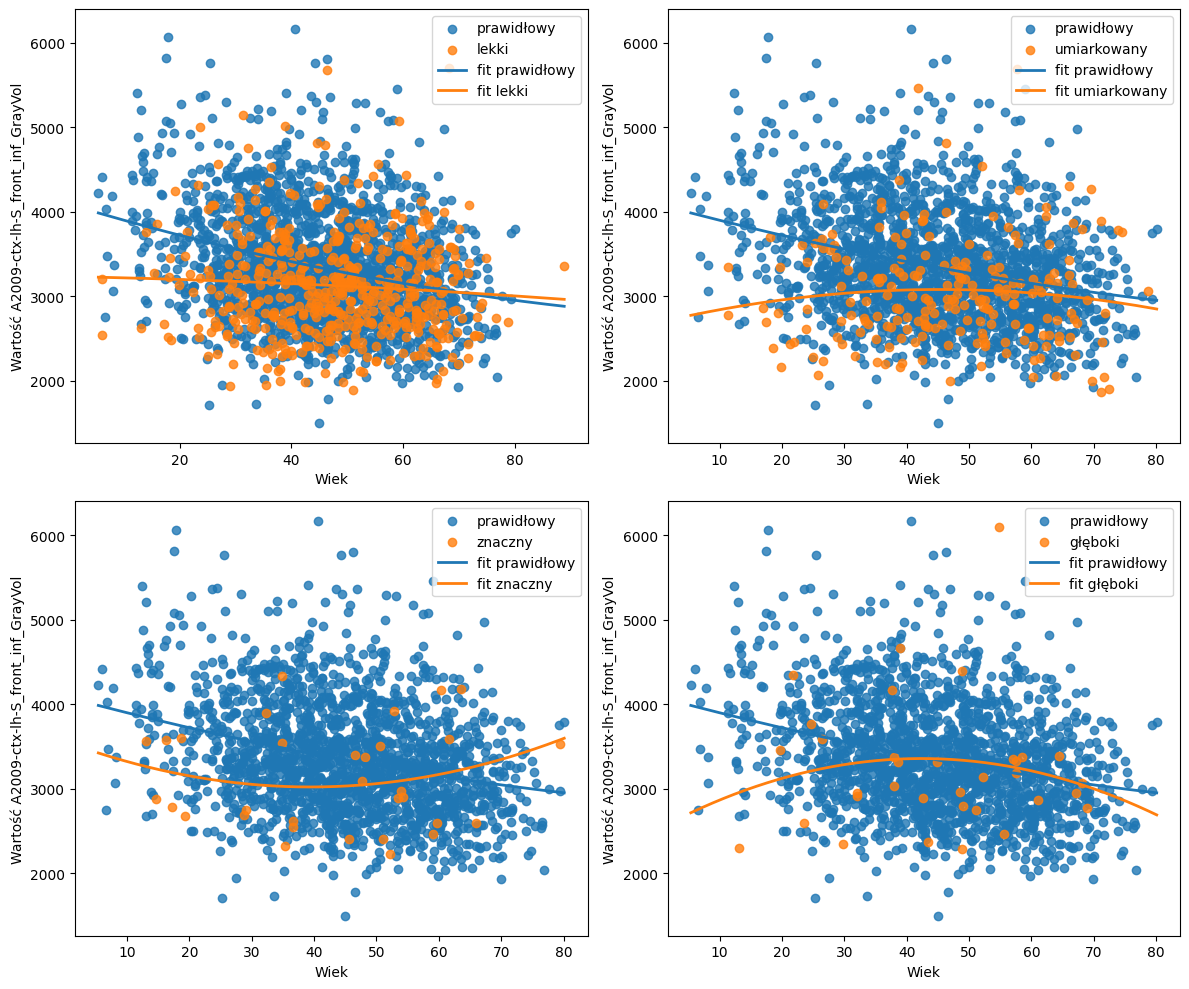

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-S_front_inf_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-S_front_inf_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-S_front_inf_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-S_front_inf_GrayVol', sex='M')

plt.tight_layout()
plt.show()

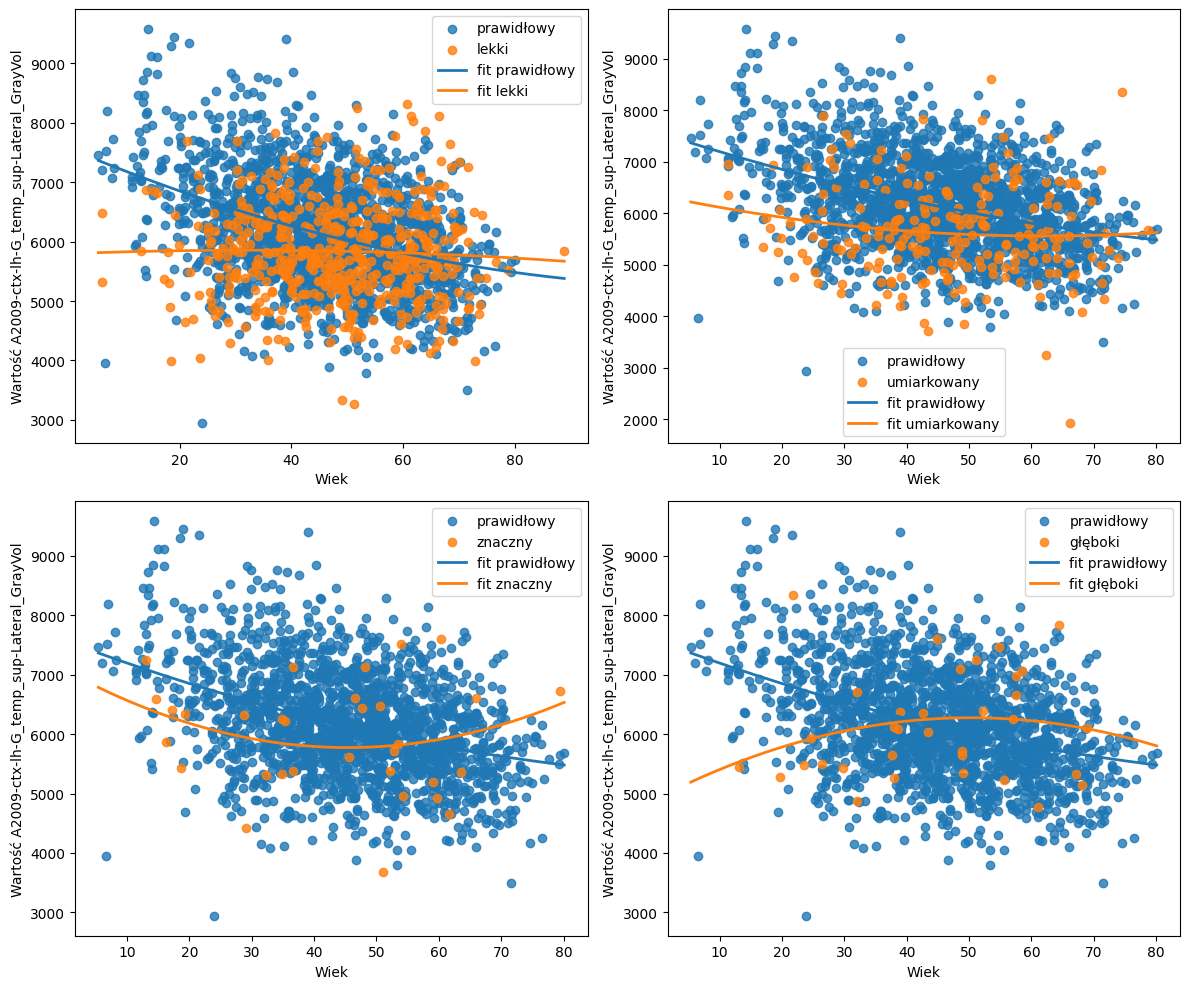

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_struct(axes[0,0], df, df_lekki, 'lekki',
            'A2009-ctx-lh-G_temp_sup-Lateral_GrayVol', sex='M')

plot_struct(axes[0,1], df, df_umiarkowany, 'umiarkowany',
            'A2009-ctx-lh-G_temp_sup-Lateral_GrayVol', sex='M')

plot_struct(axes[1,0], df, df_znaczny, 'znaczny',
            'A2009-ctx-lh-G_temp_sup-Lateral_GrayVol', sex='M')

plot_struct(axes[1,1], df, df_gleboki, 'głęboki',
            'A2009-ctx-lh-G_temp_sup-Lateral_GrayVol', sex='M')

plt.tight_layout()
plt.show()


/tmp/ipykernel_113313/4259014880.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_corrected[col] = df_all[col] - pred
/tmp/ipykernel_113313/4259014880.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_corrected[col] = df_all[col] - pred
/tmp/ipykernel_113313/4259014880.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame,

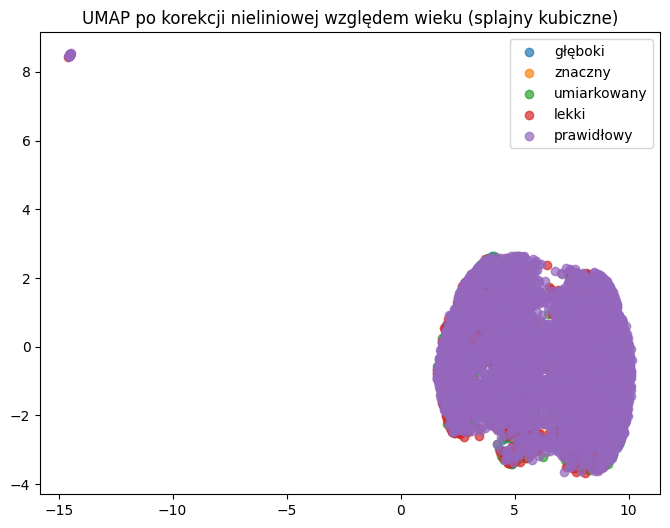

In [68]:
import pandas as pd
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import LinearRegression
import umap.umap_ as umap
import matplotlib.pyplot as plt

df_all = pd.concat([
    df_gleboki.assign(group="głęboki"),
    df_znaczny.assign(group="znaczny"),
    df_umiarkowany.assign(group="umiarkowany"),
    df_lekki.assign(group="lekki"),
    df.assign(group="prawidłowy")
], axis=0)

features = df_all.drop(columns=["group", "identifier", "norm_confirmed", "age", "female", "sex", "Unnamed:0", "DATA_BADANIA", "DATA_BADANIA_MRI", "IF_FIRST",
                                 "L_BIAP", "P_BIAP","L_HEARING_TYPE", "P_HEARING_TYPE"], errors='ignore').columns
# --- Nieliniowe modelowanie wieku ---
spline = SplineTransformer(degree=3, n_knots=6)  # 6 węzłów = dość elastyczne
age_spline = spline.fit_transform(df_all[["age"]])

X_corrected = pd.DataFrame(index=df_all.index)

for col in features:
    lr = LinearRegression()
    lr.fit(age_spline, df_all[col])
    pred = lr.predict(age_spline)
    X_corrected[col] = df_all[col] - pred

# --- UMAP ----
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean")
embedding = reducer.fit_transform(X_corrected)

plt.figure(figsize=(8,6))
for group in df_all["group"].unique():
    idx = df_all["group"] == group
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=group, alpha=0.7)

plt.legend()
plt.title("UMAP po korekcji nieliniowej względem wieku (splajny kubiczne)")
plt.show()


In [61]:
x = df_all.select_dtypes(exclude='number')


In [62]:
x

,sex,identifier,DATA_BADANIA_MRI,DATA_BADANIA,L_BIAP,P_BIAP,L_HEARING_TYPE,P_HEARING_TYPE,group
0,M,40502810321039,2011-02-14 00:00:00,2010-06-09 17:29:00,Gleboki,Gleboki,Niedosluch_odbiorczy_3,Niedosluch_odbiorczy_3,głęboki
13,M,35505609316306,2011-06-20 00:00:00,2011-04-19 11:19:00,Gleboki,Gleboki,Niedosluch_odbiorczy_3,Niedosluch_odbiorczy_3,głęboki
33,F,39504400224087,2011-03-07 00:00:00,2011-02-02 09:21:00,Gleboki,Gleboki,zaden typ nie pasuje,zaden typ nie pasuje,głęboki
57,F,31006401306150,2011-10-24 00:00:00,2011-05-26 13:36:00,Gleboki,Gleboki,Niedosluch_odbiorczy_3,Niedosluch_odbiorczy_3,głęboki
68,F,29503600824027,2011-01-27 00:00:00,2009-12-31 10:24:00,Gleboki,Gleboki,nie okreslono,nie okreslono,głęboki
...,...,...,...,...,...,...,...,...,...
10907,F,43002006614030,2024-02-21,17.01.2024 08:59,Prawidlowy,Prawidlowy,Sluch_prawidlowy,Sluch_prawidlowy,prawidłowy
10908,M,30503210607051,2024-07-30,25.01.2018 10:10,Prawidlowy,Prawidlowy,Sluch_prawidlowy,Sluch_prawidlowy,prawidłowy
10911,F,34002406826210,2024-08-26,17.10.2023 11:11,Prawidlowy,Prawidlowy,zaden typ nie pasuje,zaden typ nie pasuje,prawidłowy
10912,F,44006417718069,2024-06-17,12.11.2018 14:04,Prawidlowy,Prawidlowy,Sluch_prawidlowy,Sluch_prawidlowy,prawidłowy
